In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import numpy as np
import matplotlib.pyplot as plt
import os, zipfile, pathlib

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


In [2]:
# Download dataset directly from Microsoft (same source Kaggle used)
url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
zip_path = tf.keras.utils.get_file("cats_and_dogs.zip", origin=url, extract=False)

# Extract zip
data_dir = pathlib.Path(zip_path).parent / "PetImages"
if not data_dir.exists():
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(pathlib.Path(zip_path).parent)

# Remove corrupted images (non-JPEG files that break loading)
removed = 0
for folder in ["Cat", "Dog"]:
    for img_path in (data_dir / folder).glob("*"):
        try:
            img_bytes = tf.io.read_file(str(img_path))
            tf.image.decode_jpeg(img_bytes)
        except Exception:
            img_path.unlink()
            removed += 1

print(f"Removed {removed} corrupted images")
print("Cat images :", len(list((data_dir / 'Cat').glob('*.jpg'))))
print("Dog images :", len(list((data_dir / 'Dog').glob('*.jpg'))))


Removed 0 corrupted images
Cat images : 12427
Dog images : 12397


Found 24824 files belonging to 2 classes.
Using 19860 files for training.
Found 24824 files belonging to 2 classes.
Using 4964 files for validation.
Classes: ['Cat', 'Dog']


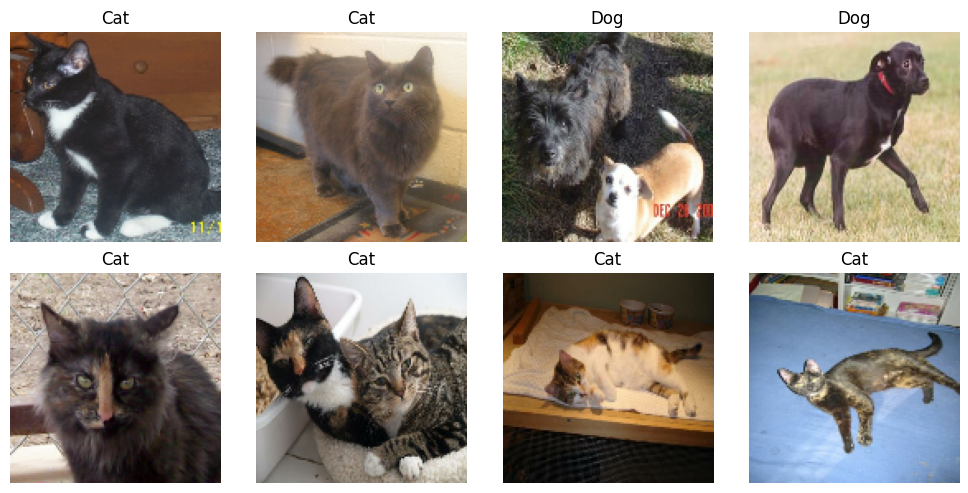

In [3]:
IMG_SIZE  = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Normalise pixel values to [0, 1] and prefetch for performance
normalization = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization(x), y)).prefetch(tf.data.AUTOTUNE)

# Visualise a sample batch
plt.figure(figsize=(10, 5))
for images, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
plt.tight_layout()
plt.show()


### CNN Model 

---

In [4]:
model = Sequential([
    keras.Input(shape=(128, 128, 3)),

    Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,312,961 (12.64 MB)

 Trainable params: 3,312,961 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [7]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 99s 156ms/step - accuracy: 0.6765 - loss: 0.5934 - val_accuracy: 0.7683 - val_loss: 0.4886
Epoch 2/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 105s 168ms/step - accuracy: 0.7799 - loss: 0.4642 - val_accuracy: 0.8100 - val_loss: 0.4154
Epoch 3/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 102s 164ms/step - accuracy: 0.8282 - loss: 0.3788 - val_accuracy: 0.8288 - val_loss: 0.3865
Epoch 4/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 113s 182ms/step - accuracy: 0.8654 - loss: 0.3120 - val_accuracy: 0.8243 - val_loss: 0.4068
Epoch 5/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 110s 176ms/step - accuracy: 0.8976 - loss: 0.2434 - val_accuracy: 0.8368 - val_loss: 0.4011
Epoch 6/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 102s 164ms/step - accuracy: 0.9353 - loss: 0.1630 - val_accuracy: 0.8288 - val_loss: 0.5768
Epoch 7/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 102s 164ms/step - accuracy: 0.9601 - loss: 0.1041 - val_accuracy: 0.8276 - val_loss: 0.5955
Epoch 8/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 100s 161ms/step - accuracy: 0.9722 - 

In [8]:
model = Sequential([
    keras.Input(shape=(128, 128, 3)),

    Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),
    
    BatchNormalization(),

    Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    BatchNormalization(),

    Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])


In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,313,345 (12.64 MB)

 Trainable params: 3,313,153 (12.64 MB)

 Non-trainable params: 192 (768.00 B)

In [10]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [11]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 113s 177ms/step - accuracy: 0.5977 - loss: 0.7142 - val_accuracy: 0.6396 - val_loss: 0.6365
Epoch 2/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 107s 172ms/step - accuracy: 0.7111 - loss: 0.5579 - val_accuracy: 0.6932 - val_loss: 0.5887
Epoch 3/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 107s 172ms/step - accuracy: 0.7862 - loss: 0.4567 - val_accuracy: 0.7923 - val_loss: 0.4400
Epoch 4/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 107s 172ms/step - accuracy: 0.8298 - loss: 0.3796 - val_accuracy: 0.8078 - val_loss: 0.4158
Epoch 5/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 110s 177ms/step - accuracy: 0.8621 - loss: 0.3156 - val_accuracy: 0.8423 - val_loss: 0.3606
Epoch 6/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 109s 175ms/step - accuracy: 0.8887 - loss: 0.2588 - val_accuracy: 0.8092 - val_loss: 0.4247
Epoch 7/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 107s 172ms/step - accuracy: 0.9113 - loss: 0.2101 - val_accuracy: 0.8517 - val_loss: 0.3537
Epoch 8/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 107s 173ms/step - accuracy: 0.9281 -